#Phase 5: Targeted Synthetic Data Augmentation

## Step 5.1: Empirically Determined Threshold (Learning Curve):

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample


In [7]:
base_dir = 'D:/Ateneo de Davao/Thesis-Project-Aspect-Based-Sentiment-Analysis/_4_Strict_Data_Parititioning'
file_path = os.path.join(base_dir, 'Train_Set_70.csv')
#----
base_dir1 = 'D:/Ateneo de Davao/Thesis-Project-Aspect-Based-Sentiment-Analysis/_4_Strict_Data_Parititioning'
file_path1 = os.path.join(base_dir1, 'Validation_Set_15.csv')

df_train= pd.read_csv(file_path)
df_val= pd.read_csv(file_path1)

In [8]:
# Drop nulls just in case the explosion phase left empty sentences
df_train = df_train.dropna(subset=['sentence', 'TargetAspect'])
df_val = df_val.dropna(subset=['sentence', 'TargetAspect'])

In [9]:
df_train

,place_name,rating,shop_type,sentence,TargetAspect
0,Hygge Coffee,4,coffee,"the atmosphere here is very nice, the crew her...",Ambiance and Atmosphere
1,WKND 1970,3,coffee,Drinks were okay.,Product Quality
2,Starbucks - SM Lanang,5,coffee,"Great Coffee, Wonderful Staff!",Product Quality
3,The Matcha Tokyo - SM Davao,3,matcha,Seems like the cashier or the order taker was ...,Customer Service
4,Cafe Demitasse,4,coffee,"The food is quite good, although the serving p...",Product Quality
...,...,...,...,...,...
16135,"KAOS CAFE - 24 Hours, Jacinto St.",4,coffee,"Their pasta is on the sweet side, so I don't k...",Product Quality
16136,Cafe Julieta,5,coffee,Delicious food and the place is so cozy,Product Quality
16137,STASH Coffee Co.,1,coffee,Rude barista.,Customer Service
16138,The Coffee Spot & Lounge,4,coffee,"Quite expensive but the food is great, relaxin...",Product Quality


In [10]:
df_val

,place_name,rating,shop_type,sentence,TargetAspect
0,Craft Coffee & Roastery,4,coffee,"They also offer a variety of food, but I only ...",Product Quality
1,Bean Xpress Matina Branch,5,coffee,Perfect also for travellers who wish to have a...,Product Quality
2,Purge Coffee Roaster,5,coffee,"Great coffee, great service.",Customer Service
3,Café Prelaya by The Joaquins’ Cheesecakes,5,coffee,Open-air seating makes up most of the area.,Store Operations and Accessibility
4,Dunkin’ | Gaisano Mall of Davao,2,coffee,Super rude cashier named AIRA!!!!,Customer Service
...,...,...,...,...,...
3454,Green Coffee - Marfori,4,coffee,Average service.. they should offer some meals.,Customer Service
3455,Blugré Coffee,4,coffee,"Blugre Coffee has that kind of feel — casual, ...",Product Quality
3456,Café de Vivré,5,coffee,Very friendly crew.,Customer Service
3457,MYLK Cafe,5,matcha,The matcha is delicious.,Product Quality


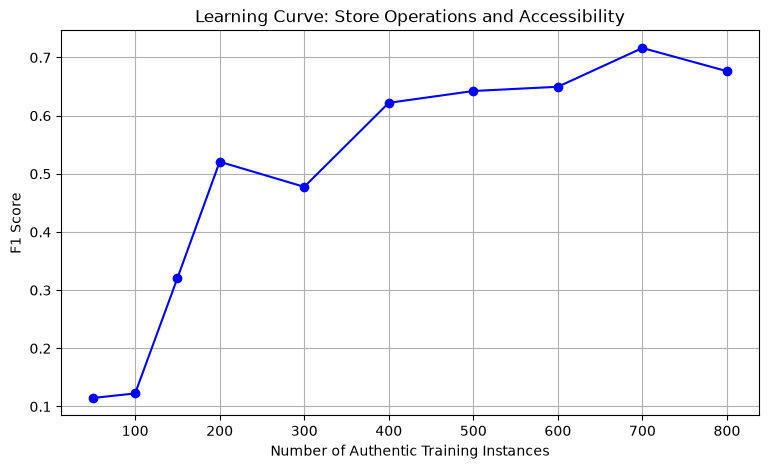

In [11]:
batch_sizes = [50, 100, 150, 200, 300, 400, 500, 600, 700, 800]
f1_scores = []

target_class = 'Store Operations and Accessibility'

y_train_binary = (df_train['TargetAspect'] == target_class).astype(int)
y_val_binary = (df_val['TargetAspect'] == target_class).astype(int)

proxy_model = make_pipeline(
    TfidfVectorizer(max_features=5000), 
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

for size in batch_sizes:
    df_subset = resample(df_train, n_samples=size, stratify=y_train_binary, random_state=42)
    X_subset = df_subset['sentence']
    y_subset = (df_subset['TargetAspect'] == target_class).astype(int)
    
    proxy_model.fit(X_subset, y_subset)
    y_pred = proxy_model.predict(df_val['sentence'])
    
    score = f1_score(y_val_binary, y_pred)
    f1_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(batch_sizes, f1_scores, marker='o', linestyle='-', color='b')
plt.title(f'Learning Curve: {target_class}')
plt.xlabel('Number of Authentic Training Instances')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()

Looking at the F-1 score, it falttens out around the 400 - 600 mark. It may spikes at 700, but rather it represents a statistical variance rather than a reliable sustained performance gain. As rules in basic Data Science, we want to reference to the flat consisdency around the 400-600 instance mark. Thus, selecting 500 instances establishes a robust and defensible baseline.

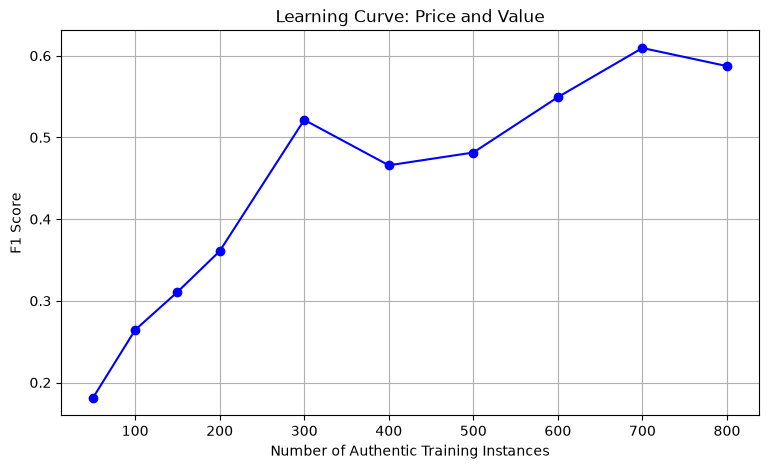

In [12]:
batch_sizes = [50, 100, 150, 200, 300, 400, 500, 600, 700, 800]
f1_scores = []

target_class = 'Price and Value'

y_train_binary = (df_train['TargetAspect'] == target_class).astype(int)
y_val_binary = (df_val['TargetAspect'] == target_class).astype(int)

proxy_model = make_pipeline(
    TfidfVectorizer(max_features=5000), 
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

for size in batch_sizes:
    df_subset = resample(df_train, n_samples=size, stratify=y_train_binary, random_state=42)
    X_subset = df_subset['sentence']
    y_subset = (df_subset['TargetAspect'] == target_class).astype(int)
    
    proxy_model.fit(X_subset, y_subset)
    y_pred = proxy_model.predict(df_val['sentence'])
    
    score = f1_score(y_val_binary, y_pred)
    f1_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(batch_sizes, f1_scores, marker='o', linestyle='-', color='b')
plt.title(f'Learning Curve: {target_class}')
plt.xlabel('Number of Authentic Training Instances')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()

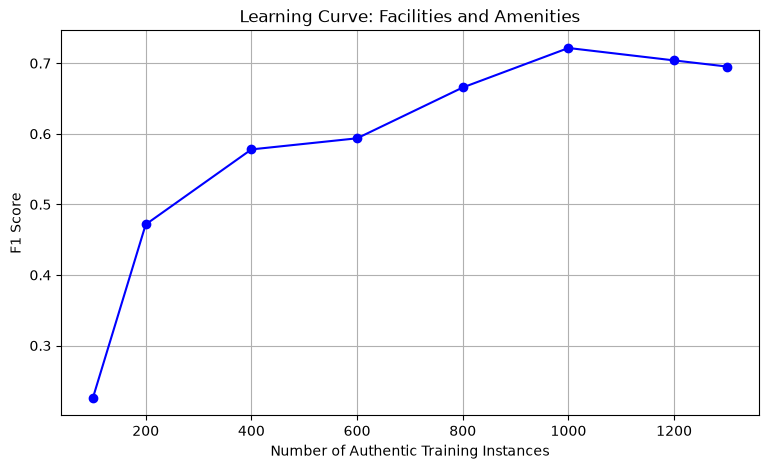

In [17]:
batch_sizes = [100, 200, 400, 600, 800, 1000, 1200, 1300] #changes for 1,300
f1_scores = []

target_class = 'Facilities and Amenities'

y_train_binary = (df_train['TargetAspect'] == target_class).astype(int)
y_val_binary = (df_val['TargetAspect'] == target_class).astype(int)

proxy_model = make_pipeline(
    TfidfVectorizer(max_features=5000), 
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

for size in batch_sizes:
    df_subset = resample(df_train, n_samples=size, stratify=y_train_binary, random_state=42)
    X_subset = df_subset['sentence']
    y_subset = (df_subset['TargetAspect'] == target_class).astype(int)
    
    proxy_model.fit(X_subset, y_subset)
    y_pred = proxy_model.predict(df_val['sentence'])
    
    score = f1_score(y_val_binary, y_pred)
    f1_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(batch_sizes, f1_scores, marker='o', linestyle='-', color='b')
plt.title(f'Learning Curve: {target_class}')
plt.xlabel('Number of Authentic Training Instances')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()

# Threshold for "Facilities and Amenities" is 1,000 instances.

# Threshold = 500 for 'Store Operations and Accessibility'

# Threshold = 600 - 700 for 'Price and Value'

The empirical learning curve analysis mandated in Step 5.1 demonstrated that all minority classes achieved performance plateaus well below their existing authentic data counts. Specifically, 'Store Operations and Accessibility' plateaued at 500 instances (out of 846), 'Price and Value' at 600-700 instances (out of 836), and 'Facilities and Amenities' at 1,000 instances (out of 1,343). Because the dataset natively exceeded these minimum viable thresholds, synthetic augmentation was bypassed entirely to prevent unnecessary noise and strictly preserve the authentic linguistic variance of the local dataset.

Furthermore, extending this threshold analysis to the majority classes was deemed unnecessary. With class distributions ranging from 2,159 to 7,728 instances, the majority categories mathematically eclipse the highest observed data sufficiency floor of 1,000 instances. Consequently, the dataset was locked as 100% human-generated text, satisfying the data requirements for Phase 6 without risking LLM-induced homogenization.